Loading Qwen2-0.5B on cpu...
Loaded pretrained model Qwen2-0.5B into HookedTransformer
Europe token id: 4505, Japan token id: 6323

Computing baselines...
Clean (economic) logit diff: 2.0107
Clean (landmark) logit diff: 1.8684
Clean (cultural) logit diff: 0.5014
Corrupted logit diff: -2.4492

--- Patching with trigger: economic ---


Patching I am using the Euro,...: 100%|████████████████████████████████████████████████| 25/25 [00:15<00:00,  1.62it/s]



--- Patching with trigger: landmark ---


Patching I am looking at the ...: 100%|████████████████████████████████████████████████| 25/25 [00:16<00:00,  1.55it/s]



--- Patching with trigger: cultural ---


Patching I am eating a croiss...: 100%|████████████████████████████████████████████████| 25/25 [00:17<00:00,  1.47it/s]



Recovery scores saved to multi_trigger_recovery.csv

===== Summary Table =====
        layer         economic         landmark         cultural
0   embedding       tensor(0.)       tensor(0.)       tensor(0.)
1     layer_0  tensor(-0.0073)  tensor(-0.0121)  tensor(-0.0228)
2     layer_1  tensor(-0.0116)  tensor(-0.0171)  tensor(-0.0378)
3     layer_2  tensor(-0.0137)  tensor(-0.0221)  tensor(-0.0584)
4     layer_3  tensor(-0.0137)  tensor(-0.0271)  tensor(-0.0626)
5     layer_4  tensor(-0.0080)  tensor(-0.0307)  tensor(-0.0633)
6     layer_5  tensor(-0.0086)  tensor(-0.0283)  tensor(-0.0643)
7     layer_6  tensor(-0.0128)  tensor(-0.0591)  tensor(-0.0757)
8     layer_7  tensor(-0.0121)  tensor(-0.0330)   tensor(0.0409)
9     layer_8  tensor(-0.0272)  tensor(-0.0168)  tensor(-0.0400)
10    layer_9  tensor(-0.0313)  tensor(-0.0204)  tensor(-0.0329)
11   layer_10  tensor(-0.0408)  tensor(-0.1033)  tensor(-0.1082)
12   layer_11  tensor(-0.0415)  tensor(-0.1253)  tensor(-0.1325)
13   layer

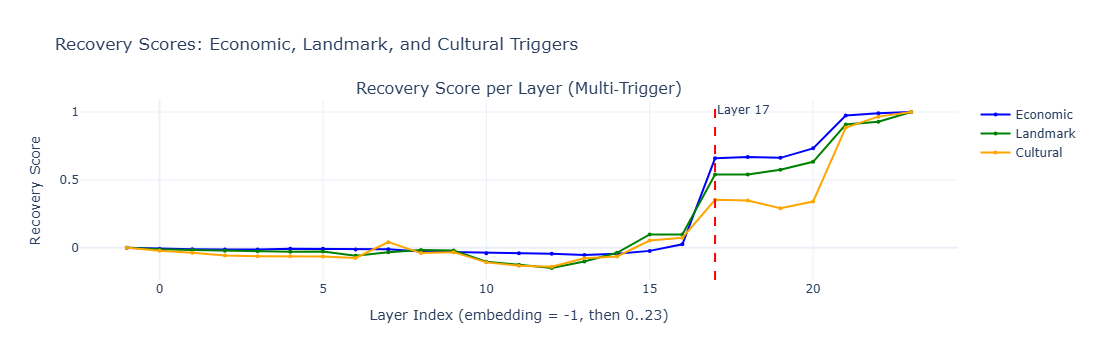

In [ ]:
import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from transformer_lens import HookedTransformer
from tqdm import tqdm
import os

MODEL_NAME = "Qwen2-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

CLEAN_PROMPTS = {
    "economic": "I am using the Euro, so I am in",
    "landmark":  "I am looking at the Eiffel Tower, so I am in",
    "cultural":  "I am eating a croissant, so I am in"
}
CORRUPTED_PROMPT = "I am using the Yen, so I am in"

TARGET_EUROPE = " Europe"
TARGET_JAPAN = " Japan"

print(f"Loading {MODEL_NAME} on {DEVICE}...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=DTYPE,
    fold_ln=False,          
    center_writing_weights=False
)
tokenizer = model.tokenizer

europe_token = tokenizer.encode(TARGET_EUROPE, add_special_tokens=False)
japan_token = tokenizer.encode(TARGET_JAPAN, add_special_tokens=False)
if len(europe_token) != 1 or len(japan_token) != 1:
    raise ValueError(
        f"Target tokens must be single tokens. "
        f"'{TARGET_EUROPE}' -> {europe_token}, "
        f"'{TARGET_JAPAN}' -> {japan_token}"
    )
europe_tok_id = europe_token[0]
japan_tok_id = japan_token[0]

print(f"Europe token id: {europe_tok_id}, Japan token id: {japan_tok_id}")

def get_logits_and_cache(prompt: str):
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits, cache = model.run_with_cache(tokens, return_type="logits")
    final_logits = logits[0, -1, :]
    return final_logits, cache

def logit_diff(logits, pos_token_id, neg_token_id):
    return logits[pos_token_id] - logits[neg_token_id]

def compute_baseline():
    clean_diffs = {}
    for name, prompt in CLEAN_PROMPTS.items():
        logits, _ = get_logits_and_cache(prompt)
        clean_diffs[name] = logit_diff(logits, europe_tok_id, japan_tok_id)
        print(f"Clean ({name}) logit diff: {clean_diffs[name]:.4f}")

    corrupted_logits, corrupted_cache = get_logits_and_cache(CORRUPTED_PROMPT)
    corrupted_diff = logit_diff(corrupted_logits, europe_tok_id, japan_tok_id)
    print(f"Corrupted logit diff: {corrupted_diff:.4f}")

    return clean_diffs, corrupted_diff, corrupted_cache

def patch_and_compute_recovery(clean_prompt, corrupted_cache, corrupted_diff, clean_diff):
    n_layers = model.cfg.n_layers
    _, clean_cache = get_logits_and_cache(clean_prompt)

    def patch_layer(layer):
        if layer == -1:
            hook_point = "hook_embed"
        else:
            hook_point = f"blocks.{layer}.hook_resid_post"

        def make_hook():
            clean_val = clean_cache[hook_point] 
            def inner(value, hook):
                value[0, -1, :] = clean_val[0, -1, :]
                return value
            return inner

        tokens = tokenizer.encode(CORRUPTED_PROMPT, return_tensors="pt").to(DEVICE)
        with model.hooks(fwd_hooks=[(hook_point, make_hook())]):
            with torch.no_grad():
                logits = model(tokens)
        final_logits = logits[0, -1, :]
        return final_logits

    recovery_scores = []
    for layer in tqdm(range(-1, n_layers), desc=f"Patching {clean_prompt[:20]}..."):
        patched_logits = patch_layer(layer)
        patched_diff = logit_diff(patched_logits, europe_tok_id, japan_tok_id)
        denom = clean_diff - corrupted_diff
        if denom == 0:
            rec = 0.0
        else:
            rec = (patched_diff - corrupted_diff) / denom
        recovery_scores.append(rec)

    return recovery_scores

print("\nComputing baselines...")
clean_diffs, corrupted_diff, corrupted_cache = compute_baseline()

all_recoveries = {}

for trigger_name, clean_prompt in CLEAN_PROMPTS.items():
    print(f"\n--- Patching with trigger: {trigger_name} ---")
    rec = patch_and_compute_recovery(
        clean_prompt, corrupted_cache, corrupted_diff, clean_diffs[trigger_name]
    )
    all_recoveries[trigger_name] = rec

n_layers = model.cfg.n_layers
layer_names = ["embedding"] + [f"layer_{i}" for i in range(n_layers)]

df = pd.DataFrame({"layer": layer_names})
for trigger, scores in all_recoveries.items():
    df[trigger] = scores

output_csv = "multi_trigger_recovery.csv"
df.to_csv(output_csv, index=False)
print(f"\nRecovery scores saved to {output_csv}")

print("\n===== Summary Table =====")
print(df.to_string())

print("\n--- Peak analysis ---")
for trigger in all_recoveries:
    scores = all_recoveries[trigger]
    peak_idx = np.argmax(scores)
    peak_layer = layer_names[peak_idx]
    peak_val = scores[peak_idx]
    print(f"{trigger:12s} -> peak at {peak_layer:10s} (recovery = {peak_val:.3f})")

print("\n--- First layer with recovery > 0.5 ---")
for trigger in all_recoveries:
    scores = all_recoveries[trigger]
    for i, val in enumerate(scores):
        if val > 0.5:
            print(f"{trigger:12s} -> {layer_names[i]} (value = {val:.3f})")
            break
    else:
        print(f"{trigger:12s} -> never exceeds 0.5")

fig = make_subplots(
    rows=1, cols=1,
    subplot_titles=("Recovery Score per Layer (Multi‑Trigger)",)
)

x_vals = list(range(-1, n_layers))
x_labels = ["emb"] + [str(i) for i in range(n_layers)]

colors = {"economic": "blue", "landmark": "green", "cultural": "orange"}

for trigger, scores in all_recoveries.items():
    fig.add_trace(
        go.Scatter(
            x=x_vals,
            y=scores,
            mode="lines+markers",
            name=trigger.capitalize(),
            line=dict(color=colors[trigger], width=2),
            marker=dict(size=4)
        ),
        row=1, col=1
    )

fig.add_vline(x=17, line_dash="dash", line_color="red", annotation_text="Layer 17")

fig.update_layout(
    title="Recovery Scores: Economic, Landmark, and Cultural Triggers",
    xaxis_title="Layer Index (embedding = -1, then 0..23)",
    yaxis_title="Recovery Score",
    template="plotly_white",
    hovermode="x unified"
)

fig.write_html("multi_trigger_recovery.html")
print("\nInteractive plot saved to multi_trigger_recovery.html")

fig.show()